In [1]:
import torch
import json
import os

from data.ae_dataset import AEDataset
from torch import linalg as LA
import numpy as np

In [2]:
from model.autoencoder import AutoEncoder
from config.configAE import ConfigAE
from data.ae_dataset import get_dataloader

/home/ubuntu/mechanism-identification/venv_py38/lib/python3.8/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2023-07-18 08:42:42,705 - INFO: Created a temporary directory at /tmp/tmp_f5w3fjm
2023-07-18 08:42:42,706 - INFO: Writing /tmp/tmp_f5w3fjm/_remote_module_non_scriptable.py


In [3]:
from matplotlib.pyplot import plot

In [4]:
dataset = AEDataset("train")

In [5]:
out_vectors = torch.load("model_outputs/out_train_0717_170857.pt")

In [6]:
UNIT = 512
TOTAL = 5120
N_NUM = 9

all_norm_list = []
for item in out_vectors:
    cnt = 0
    norm_list = []
    while cnt <= N_NUM:
        start_idx = cnt * UNIT
        chunk = item[start_idx:start_idx+UNIT]
        norm_list.append(LA.norm(chunk).item())
        cnt += 1
    all_norm_list.append(norm_list)

In [7]:
all_norm_list[0]

[0.9663159251213074,
 0.9696786403656006,
 0.9670835137367249,
 0.024068312719464302,
 0.549070417881012,
 0.6139183640480042,
 0.7196806073188782,
 0.7703955769538879,
 0.8134360313415527,
 0.7662778496742249]

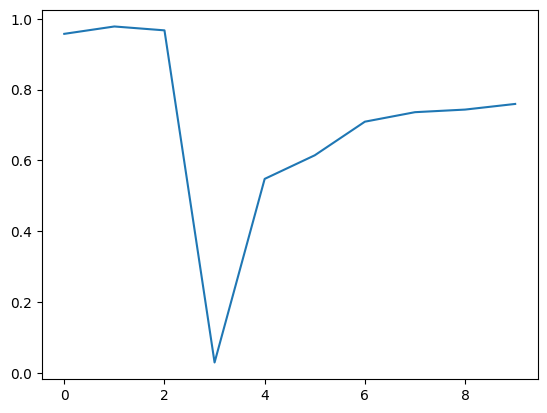

In [9]:
plot(range(10), all_norm_list[1237])